In [1]:
from store_activation import CorrelationBasedNeuronAttribution
from LKN.utils import get_model

model_name = "meta-llama/Meta-Llama-3-8B-Instruct"
model, tokenizer = get_model(model_name)

/home/bumjin/anaconda3/lib/python3.11/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!
/home/bumjin/anaconda3/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/bumjin/anaconda3/lib/python3.11/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
2025-11-26 07:06:52.246625: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation 

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [2]:
import json 

json_file = open("data/sample.json", "r")
data = json.load(json_file)
concept = "나이"

positive_samples = [sample for sample in data[concept]["pos"]]
negative_samples = [sample for sample in data[concept]["neg"]]

In [11]:
import torch 
import numpy as np 
from LKN.utils import get_llm_block
from tqdm import tqdm

class KeyHiddenStateHook:
    def __init__(self):
        self.hidden_states = None
        self.probe_positions = None
        
    def __call__(self, module, input, output):
        # Store hidden states on CPU immediately and convert to float16
        self.hidden_states = []
        for i  in range(self.probe_positions.shape[0]):
            probe_position = self.probe_positions[i]
            self.hidden_states.append(input[0][i, probe_position, :].clone().detach().cpu().half())
        self.hidden_states = torch.stack(self.hidden_states)
        
    def clear(self):
        self.hidden_states = None


class CorrelationBasedNeuronAttribution:
    def __init__(self, model, tokenizer, model_name):
        self.model = model
        self.tokenizer = tokenizer
        self.model_name = model_name
        
    def batchifed_tokenize(self, samples, batch_size):
        self.tokenizer.pad_token = self.tokenizer.eos_token
        self.tokenizer.padding_side = 'left'
        input_ids = [] 
        attention_mask = []
        num_batch = len(samples) // batch_size + 1 if len(samples) % batch_size != 0 else len(samples) // batch_size
        for i in range(num_batch):
            batch_samples = samples[i*batch_size:(i+1)*batch_size]
            inputs = self.tokenizer(batch_samples, return_tensors="pt", padding=True, truncation=True)
            input_ids.append(inputs.input_ids)
            attention_mask.append(inputs.attention_mask)
        return input_ids, attention_mask

    def store_activation(self, positive_samples, negative_samples, batch_size):
        blocks = get_llm_block(self.model, self.model_name)
        layer_indices = list(range(len(blocks)))
        hooks = []
        hook_handles = []
        for layer_idx in layer_indices:
            hook = KeyHiddenStateHook()
            # last six tokens
            hook.probe_positions = torch.tensor([[-6, -5, -4, -3, -2, -1]]).repeat(batch_size, 1)
            key_activation =  blocks[layer_idx].mlp.down_proj
            hook_handle = key_activation.register_forward_hook(hook)
            hooks.append(hook)
            hook_handles.append(hook_handle)
            
        means = {}
        variances = {}
        corrs = {}
        layer_key_hidden_states = {}
        for samples, label in zip([positive_samples, negative_samples], ["positive", "negative"]):
            means[label] = {}
            variances[label] = {}
            layer_key_hidden_states[label] = {layer: [] for layer in layer_indices}
            input_ids_all, attention_mask_all = self.batchifed_tokenize(samples, batch_size)
            
            for i in range(len(input_ids_all)):
                input_ids = input_ids_all[i]
                attention_mask = attention_mask_all[i]
                with torch.no_grad():
                    output = self.model(input_ids, attention_mask=attention_mask)
                
                for index, sample in enumerate(samples):
                    for idx, layer_idx in enumerate(layer_indices):
                        key_hidden_states = hooks[idx].hidden_states  # Shape: [batch_size, sequence_length, hidden_size]
                        last_token_key_hidden_state = key_hidden_states[index,:,:]  # Shape: [hidden_size]
                        last_token_key_hidden_state = last_token_key_hidden_state.reshape(-1, last_token_key_hidden_state.shape[-1])
                        layer_key_hidden_states[label][layer_idx].append(last_token_key_hidden_state)

        for layer_idx in tqdm(layer_indices):
            corrs[layer_idx] = {}
            concat_input = []
            concat_target = []
            for label in ["positive", "negative"]:
                layer_key_hidden_states[label][layer_idx] = torch.concat(layer_key_hidden_states[label][layer_idx], dim=0)
                means[label][layer_idx] = layer_key_hidden_states[label][layer_idx].mean(dim=0).detach().cpu()
                variances[label][layer_idx] = layer_key_hidden_states[label][layer_idx].var(dim=0).detach().cpu()
                concat_input.append(layer_key_hidden_states[label][layer_idx])
                if label == "positive":
                    concat_target.append(torch.ones(len(layer_key_hidden_states[label][layer_idx])))
                else:
                    concat_target.append(torch.zeros(len(layer_key_hidden_states[label][layer_idx])))
            concat_input = torch.concat(concat_input, dim=0)
            concat_target = torch.concat(concat_target, dim=0)
            for neuron_index in range(concat_input.shape[1]):
                corrs[layer_idx][neuron_index] = np.corrcoef(concat_input[:,neuron_index].numpy(), 
                                                             concat_target[:].numpy())[0,1]
    
        for hook in hooks:
            hook.clear()
        
        self.means = means
        self.variances = variances
        self.corrs = corrs

atr = CorrelationBasedNeuronAttribution(model, tokenizer, model_name)

batch_size = 10
atr.store_activation(positive_samples, negative_samples, batch_size)

100%|██████████| 32/32 [00:32<00:00,  1.02s/it]


In [38]:
num_layers = len(atr.means["positive"])
num_neurons = atr.means["positive"][0].shape[0]
def get_neuron_info(layer_idx, neuron_index):
    return {'pos_mean': atr.means["positive"][layer_idx][neuron_index].item(), 
            'pos_var': atr.variances["positive"][layer_idx][neuron_index].item(), 
            'neg_mean': atr.means["negative"][layer_idx][neuron_index].item(), 
            'neg_var': atr.variances["negative"][layer_idx][neuron_index].item(), 
            'corr': atr.corrs[layer_idx][neuron_index]}
print("num_layers", num_layers)
print("num_neurons", num_neurons)

all_corrs = []
for layer_idx in range(num_layers):
    for neuron_index in range(num_neurons):
        all_corrs.append(get_neuron_info(layer_idx, neuron_index)["corr"])
all_corrs = np.array(all_corrs)

num_layers 32
num_neurons 14336


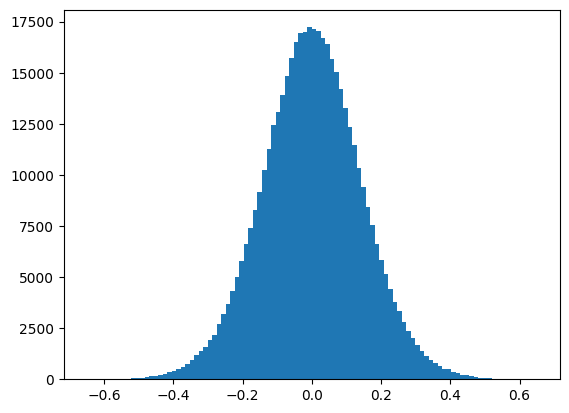

In [39]:
import matplotlib.pyplot as plt
plt.hist(all_corrs, bins=100)
plt.show()

In [ ]:
def index_to_layer_and_neuron(index):
    return index // num_neurons, index % num_neurons

top_k_neurons = np.argsort(-all_corrs)[:10]
print("top 10 neurons")
print(f"layer | Neuron |   corr   |   pos_mean   |   neg_mean   |")
for neuron_index in top_k_neurons:
    layer_idx, neuron_index = index_to_layer_and_neuron(neuron_index)
    info = get_neuron_info(layer_idx, neuron_index)
    print(f"{layer_idx:7d} | {neuron_index:6d} | {info['corr']:7.3f} | {info['pos_mean']:7.3f} | {info['neg_mean']:7.3f} |")

top 10 neurons
layer | Neuron |   corr   |   pos_mean   |   neg_mean   |
      9 |   9175 |   0.651 |   0.053 |   0.000 |
     17 |   2862 |   0.649 |   0.057 |   0.001 |
      9 |   8343 |   0.642 |   0.025 |  -0.007 |
     13 |   8305 |   0.637 |   0.074 |   0.022 |
      9 |   9494 |   0.626 |   0.018 |  -0.030 |
      9 |   7252 |   0.625 |   0.014 |  -0.028 |
      9 |   3445 |   0.618 |   0.034 |  -0.021 |
     13 |   3914 |   0.616 |  -0.000 |  -0.047 |
     14 |   3458 |   0.610 |   0.007 |  -0.047 |
      9 |   8366 |   0.605 |   0.006 |  -0.026 |
